# K-Means Clustering Polutan

Dokumen ini menjelaskan proses pengelompokan (clustering) area berdasarkan tingkat dan karakteristik polutan (dalam hal ini NO2). Setelah melakukan ekstraksi fitur (menggunakan TSFEL) pada data deret waktu polutan dari area Kwanyar dan digabungkan dengan data dari area milik teman sekelas.

Tujuan dari tahapan ini adalah untuk menemukan daerah-daerah mana saja yang memiliki karakteristik, tren, dan pola polusi yang serupa.

## 1. Implementasi K-Means dengan Python (Scikit-Learn)

Untuk mengimplementasikan rekomendasi di atas, kita dapat menggunakan bahasa pemrograman Python dengan *library* **Scikit-Learn** (`sklearn`). Library ini adalah standar industri yang sangat bagus dan stabil untuk pemodelan *Machine Learning* konvensional seperti PCA dan K-Means.

### 1.1 Evaluasi Jumlah Cluster (Elbow Method)

Untuk mengetahui berapa cluster yang paling optimal, kita menggunakan **Elbow Method**. Kita akan melatih model K-Means dengan variasi jumlah cluster (misalnya $K=2$ sampai $K=10$), lalu menghitung nilai inersia (jarak kuadrat rata-rata ke pusat cluster).

```python
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('./source/Ekstraksi_fitur/ekstraksi_fitur_nama_polutan.csv')
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)
fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(fitur_pca)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Evaluasi Jumlah Cluster dengan Elbow Method')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (Jarak Kuadrat)')
plt.grid(True)
plt.show()
```

**NO2**

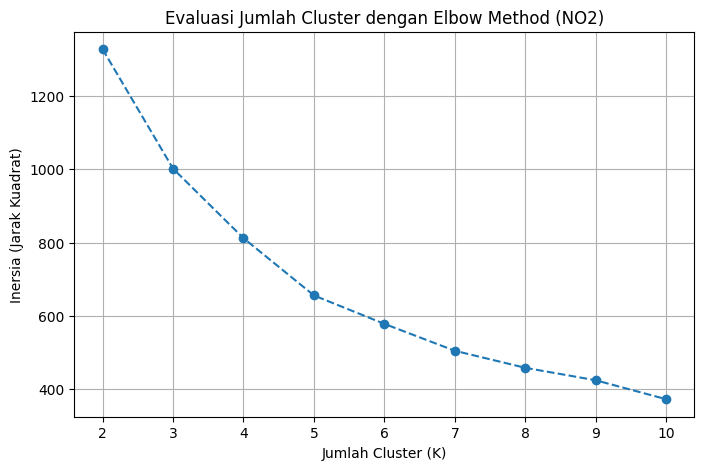

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('ekstraksi_fitur_no2.csv')
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)
fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(fitur_pca)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Evaluasi Jumlah Cluster dengan Elbow Method (NO2)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (Jarak Kuadrat)')
plt.grid(True)
plt.show()

**2) CO2**

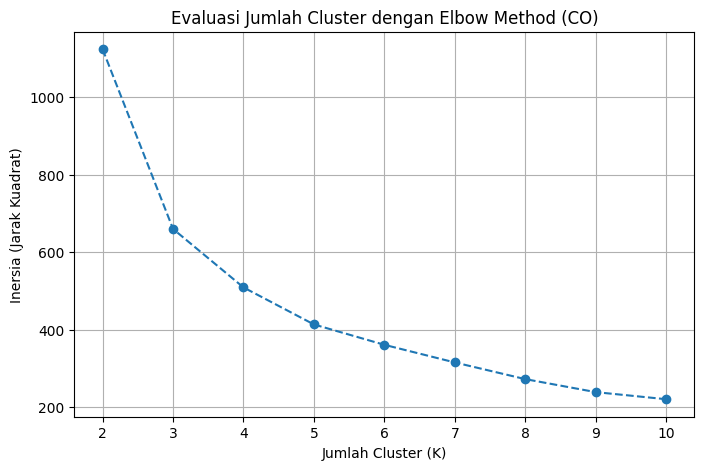

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('ekstraksi_fitur_co.csv')
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)
fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(fitur_pca)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Evaluasi Jumlah Cluster dengan Elbow Method (CO)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (Jarak Kuadrat)')
plt.grid(True)
plt.show()

**SO2**

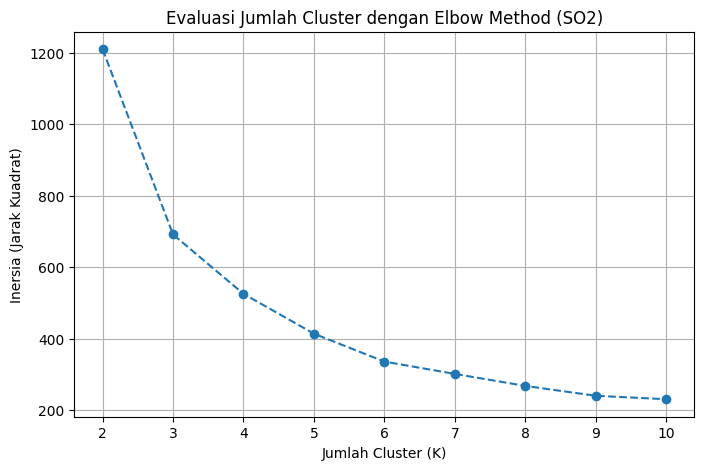

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('ekstraksi_fitur_so2.csv')
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)
fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(fitur_pca)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Evaluasi Jumlah Cluster dengan Elbow Method (SO2)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (Jarak Kuadrat)')
plt.grid(True)
plt.show()

*Catatan: Anda akan melihat patahan siku (elbow) pada grafik di atas. Jika patahannya paling tajam di angka 6, maka $K=6$ adalah pilihan yang tepat.*

### 1.2 Visualisasi Scatter Plot PCA dan Profiling

Setelah menentukan menggunakan $K=6$, kita jalankan algoritma K-Means final. Kemudian kita membuat **Scatter Plot PCA** menggunakan PCA 1 dan PCA 2 untuk melihat apakah klaster terpisah dengan baik secara matematis.

```python
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Memuat Data
df = pd.read_csv('./source/Ekstraksi_fitur/ekstraksi_fitur_nama_polutan.csv')
identitas = df[['id', 'nama', 'daerah']]
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

# 2. Standardisasi & PCA
scaler = StandardScaler()
fitur_pca = PCA(n_components=37).fit_transform(scaler.fit_transform(fitur))

# 3. K-Means (K=6)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmeans.fit_predict(fitur_pca)

df_hasil = identitas.copy()
df_hasil['Cluster'] = clusters

# 4. Visualisasi Scatter Plot
plt.figure(figsize=(15, 7))
sns.scatterplot(x=df_hasil['daerah'], y=df_hasil['Cluster'], hue=df_hasil['Cluster'], palette='tab10', s=100)
plt.title('Scatter Plot Persebaran Daerah per Cluster (NAMA_POLUTAN)')
plt.xlabel('Nama Daerah')
plt.ylabel('Cluster')
plt.xticks(rotation=90)
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# 5. Menampilkan profil klaster berdasarkan daerah (Top 3 per klaster)
profil_daerah = df_hasil.groupby(['Cluster', 'daerah']).size().reset_index(name='Jumlah')
top_3_per_cluster = profil_daerah.sort_values(by=['Cluster', 'Jumlah'], ascending=[True, False]).groupby('Cluster').head(3)
print(top_3_per_cluster)
```

**NO2**

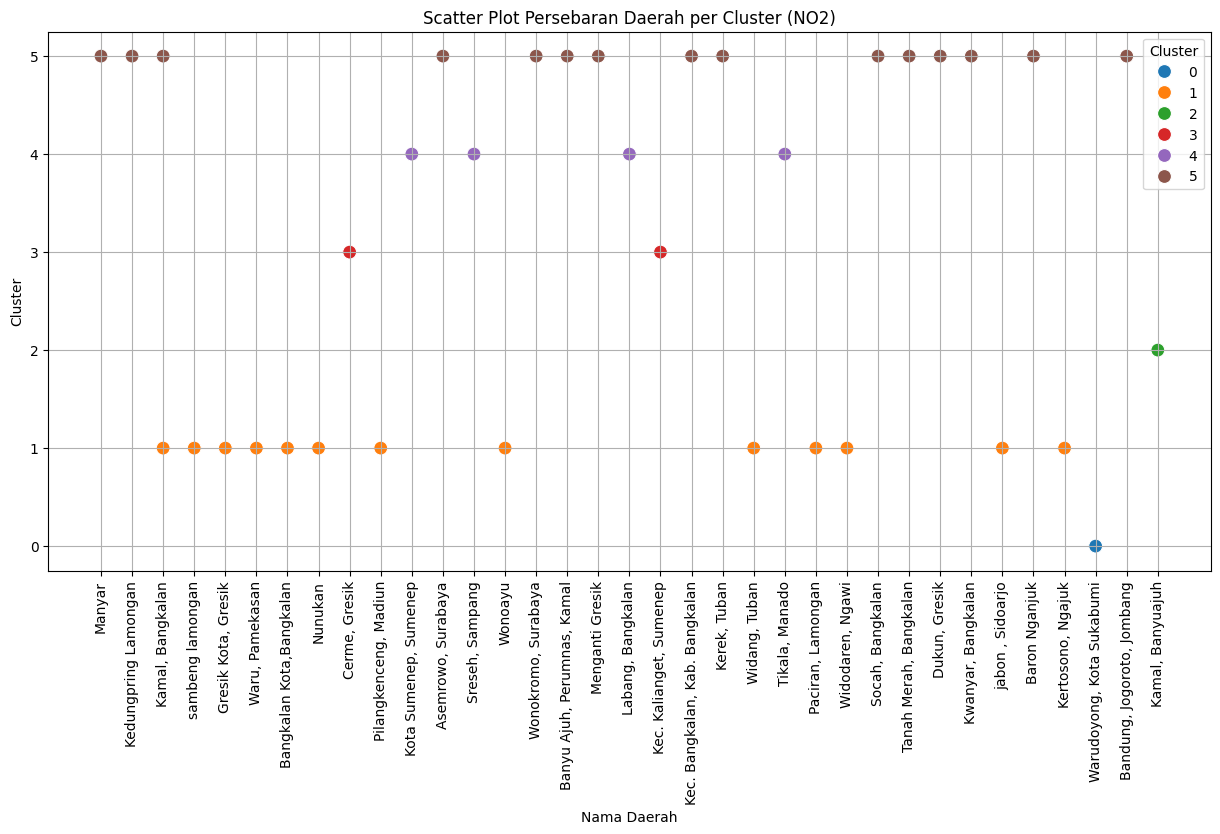

    Cluster                      daerah  Jumlah
0         0   Warudoyong, Kota Sukabumi       1
1         1    Bangkalan Kota,Bangkalan       1
2         1         Gresik Kota, Gresik       1
3         1            Kamal, Bangkalan       1
14        2            Kamal, Banyuajuh       1
15        3               Cerme, Gresik       1
16        3     Kec. Kalianget, Sumenep       1
17        4       Kota Sumenep, Sumenep       1
18        4           Labang, Bangkalan       1
19        4             Sreseh, Sampang       1
30        5          Kwanyar, Bangkalan       2
21        5          Asemrowo, Surabaya       1
22        5  Bandung, Jogoroto, Jombang       1


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Memuat Data
df = pd.read_csv('ekstraksi_fitur_no2.csv')
identitas = df[['id', 'nama', 'daerah']]
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

# 2. Standardisasi & PCA
scaler = StandardScaler()
fitur_pca = PCA(n_components=37).fit_transform(scaler.fit_transform(fitur))

# 3. K-Means (K=6)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmeans.fit_predict(fitur_pca)

df_hasil = identitas.copy()
df_hasil['Cluster'] = clusters

# 4. Visualisasi Scatter Plot
plt.figure(figsize=(15, 7))
sns.scatterplot(x=df_hasil['daerah'], y=df_hasil['Cluster'], hue=df_hasil['Cluster'], palette='tab10', s=100)
plt.title('Scatter Plot Persebaran Daerah per Cluster (NO2)')
plt.xlabel('Nama Daerah')
plt.ylabel('Cluster')
plt.xticks(rotation=90)
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# 5. Menampilkan profil klaster berdasarkan daerah (Top 3 per klaster)
profil_daerah = df_hasil.groupby(['Cluster', 'daerah']).size().reset_index(name='Jumlah')
top_3_per_cluster = profil_daerah.sort_values(by=['Cluster', 'Jumlah'], ascending=[True, False]).groupby('Cluster').head(3)
print(top_3_per_cluster)

**CO**

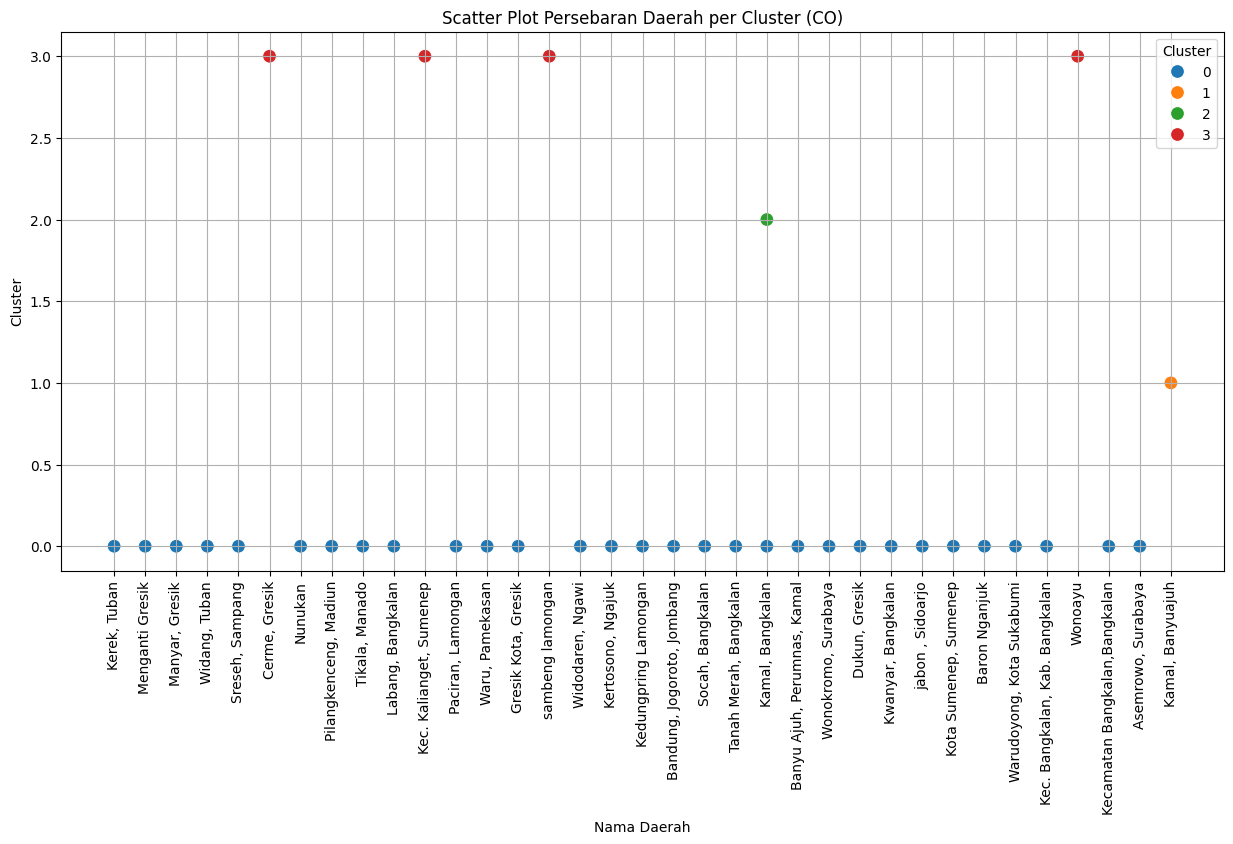

    Cluster                      daerah  Jumlah
13        0          Kwanyar, Bangkalan       2
0         0          Asemrowo, Surabaya       1
1         0  Bandung, Jogoroto, Jombang       1
30        1            Kamal, Banyuajuh       1
31        2            Kamal, Bangkalan       1
32        3               Cerme, Gresik       1
33        3     Kec. Kalianget, Sumenep       1
34        3                     Wonoayu       1


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Memuat Data
df = pd.read_csv('ekstraksi_fitur_co.csv')
identitas = df[['id', 'nama', 'daerah']]
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

# 2. Standardisasi & PCA
scaler = StandardScaler()
fitur_pca = PCA(n_components=37).fit_transform(scaler.fit_transform(fitur))

# 3. K-Means (K=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(fitur_pca)

df_hasil = identitas.copy()
df_hasil['Cluster'] = clusters

# 4. Visualisasi Scatter Plot
plt.figure(figsize=(15, 7))
sns.scatterplot(x=df_hasil['daerah'], y=df_hasil['Cluster'], hue=df_hasil['Cluster'], palette='tab10', s=100)
plt.title('Scatter Plot Persebaran Daerah per Cluster (CO)')
plt.xlabel('Nama Daerah')
plt.ylabel('Cluster')
plt.xticks(rotation=90)
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# 5. Menampilkan profil klaster berdasarkan daerah (Top 3 per klaster)
profil_daerah = df_hasil.groupby(['Cluster', 'daerah']).size().reset_index(name='Jumlah')
top_3_per_cluster = profil_daerah.sort_values(by=['Cluster', 'Jumlah'], ascending=[True, False]).groupby('Cluster').head(3)
print(top_3_per_cluster)

**SO2**

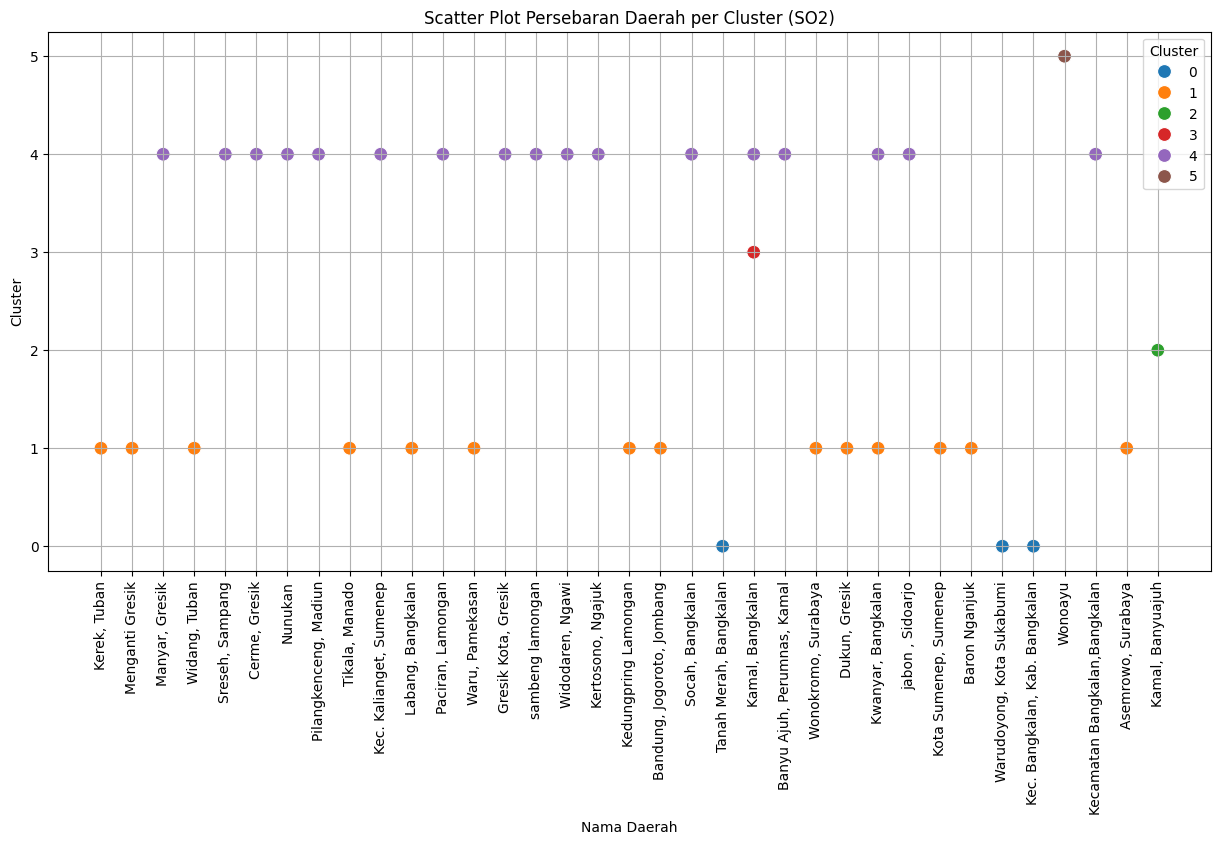

    Cluster                          daerah  Jumlah
0         0  Kec. Bangkalan, Kab. Bangkalan       1
1         0          Tanah Merah, Bangkalan       1
2         0       Warudoyong, Kota Sukabumi       1
3         1              Asemrowo, Surabaya       1
4         1      Bandung, Jogoroto, Jombang       1
5         1                   Baron Nganjuk       1
17        2                Kamal, Banyuajuh       1
18        3                Kamal, Bangkalan       1
19        4     Banyu Ajuh, Perumnas, Kamal       1
20        4                   Cerme, Gresik       1
21        4             Gresik Kota, Gresik       1
36        5                         Wonoayu       1


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Memuat Data
df = pd.read_csv('ekstraksi_fitur_so2.csv')
identitas = df[['id', 'nama', 'daerah']]
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

# 2. Standardisasi & PCA
scaler = StandardScaler()
fitur_pca = PCA(n_components=37).fit_transform(scaler.fit_transform(fitur))

# 3. K-Means (K=6)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmeans.fit_predict(fitur_pca)

df_hasil = identitas.copy()
df_hasil['Cluster'] = clusters

# 4. Visualisasi Scatter Plot
plt.figure(figsize=(15, 7))
sns.scatterplot(x=df_hasil['daerah'], y=df_hasil['Cluster'], hue=df_hasil['Cluster'], palette='tab10', s=100)
plt.title('Scatter Plot Persebaran Daerah per Cluster (SO2)')
plt.xlabel('Nama Daerah')
plt.ylabel('Cluster')
plt.xticks(rotation=90)
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# 5. Menampilkan profil klaster berdasarkan daerah (Top 3 per klaster)
profil_daerah = df_hasil.groupby(['Cluster', 'daerah']).size().reset_index(name='Jumlah')
top_3_per_cluster = profil_daerah.sort_values(by=['Cluster', 'Jumlah'], ascending=[True, False]).groupby('Cluster').head(3)
print(top_3_per_cluster)

## 2. Analisis Lanjutan: Hopkins Statistic & Perbandingan PCA (37) vs 68 Fitur Asli

Bagian 1 di atas menjalankan Elbow Method per polutan secara terpisah dan langsung memakai $k$ tertentu (mis. $K=6$) tanpa pengukuran objektif. Bagian ini melengkapinya dengan:

1. **Hopkins Statistic** — mengecek dulu apakah data memang punya kecenderungan cluster, sebelum menentukan $k$.
2. **Silhouette Score** sebagai penentu $k$ terbaik yang lebih objektif dibanding elbow saja.
3. Perbandingan hasil clustering antara data **hasil PCA (37 komponen)** vs **68 fitur asli (tanpa PCA)**, untuk ketiga polutan **NO2, CO, SO2** sekaligus.

> Catatan: karena bagian 1 memuat data per polutan secara terpisah di tiap blok kode, bagian ini memuat ulang ketiga file sekaligus ke satu struktur (`raw`/`processed`) supaya bisa dibandingkan berdampingan.

In [8]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 110
np.random.seed(42)

FILES = {
    "NO2": "ekstraksi_fitur_no2.csv",
    "CO":  "ekstraksi_fitur_co.csv",
    "SO2": "ekstraksi_fitur_so2.csv",
}

raw = {}
for name, path in FILES.items():
    df = pd.read_csv(path)
    raw[name] = df
    print(f"--- {name} ---")
    print(f"  Jumlah baris (sampel/lokasi) : {df.shape[0]}")
    print(f"  Jumlah kolom fitur           : {df.shape[1] - 3}  (di luar id, nama, daerah)")
    print(f"  Total nilai NaN              : {df.isna().sum().sum()}")
    print()

--- NO2 ---
  Jumlah baris (sampel/lokasi) : 37
  Jumlah kolom fitur           : 68  (di luar id, nama, daerah)
  Total nilai NaN              : 0

--- CO ---
  Jumlah baris (sampel/lokasi) : 37
  Jumlah kolom fitur           : 68  (di luar id, nama, daerah)
  Total nilai NaN              : 0

--- SO2 ---
  Jumlah baris (sampel/lokasi) : 37
  Jumlah kolom fitur           : 68  (di luar id, nama, daerah)
  Total nilai NaN              : 0



### Preprocessing

Sebelum Hopkins Statistic dan PCA, tiap dataset polutan diproses dulu: isi NaN dengan median, buang fitur yang variansinya nol (konstan), lalu standardisasi (z-score).

In [9]:
def preprocess(df):
    feat_cols = [c for c in df.columns if c not in ["id", "nama", "daerah"]]
    X = df[feat_cols].copy()
    X = X.fillna(X.median(numeric_only=True))

    nunique = X.nunique()
    const_cols = nunique[nunique <= 1].index.tolist()
    if const_cols:
        X = X.drop(columns=const_cols)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X, X_scaled, const_cols

processed = {}
for name, df in raw.items():
    X, X_scaled, dropped = preprocess(df)
    processed[name] = {"X": X, "X_scaled": X_scaled, "dropped": dropped}
    print(f"{name}: {X.shape[1]} fitur dipakai (dari 68) setelah membuang {len(dropped)} fitur konstan -> {dropped}")

NO2: 66 fitur dipakai (dari 68) setelah membuang 2 fitur konstan -> ['human_range_energy', 'spectral_roll_on']
CO: 65 fitur dipakai (dari 68) setelah membuang 3 fitur konstan -> ['human_range_energy', 'spectral_roll_on', 'zero_cross']
SO2: 66 fitur dipakai (dari 68) setelah membuang 2 fitur konstan -> ['human_range_energy', 'spectral_roll_on']


## 4. Hopkins Statistic — Cek Kecenderungan Cluster (Sebelum Menentukan k)

In [10]:
def hopkins_statistic(X, sample_ratio=0.3, random_state=42):
    rng = np.random.RandomState(random_state)
    n = X.shape[0]
    m = max(2, int(sample_ratio * n))

    nbrs = NearestNeighbors(n_neighbors=2).fit(X)

    # (a) jarak titik ASLI data ke tetangga terdekatnya (bukan dirinya sendiri)
    idx = rng.choice(n, m, replace=False)
    u_dist = [nbrs.kneighbors(X[i].reshape(1, -1), n_neighbors=2)[0][0][1] for i in idx]

    # (b) jarak titik ACAK (uniform, dalam bounding box data) ke titik data terdekat
    mins, maxs = X.min(axis=0), X.max(axis=0)
    rand_pts = rng.uniform(mins, maxs, size=(m, X.shape[1]))
    w_dist = [nbrs.kneighbors(p.reshape(1, -1), n_neighbors=1)[0][0][0] for p in rand_pts]

    U, W = np.sum(u_dist), np.sum(w_dist)
    return W / (U + W)

for name, d in processed.items():
    h = hopkins_statistic(d["X_scaled"])
    processed[name]["hopkins"] = h
    if h > 0.75:
        ket = "kecenderungan cluster KUAT"
    elif h > 0.6:
        ket = "kecenderungan cluster CUKUP"
    else:
        ket = "kecenderungan cluster LEMAH / mendekati acak"
    print(f"{name}: Hopkins Statistic = {h:.3f}  -> {ket}")

NO2: Hopkins Statistic = 0.842  -> kecenderungan cluster KUAT
CO: Hopkins Statistic = 0.880  -> kecenderungan cluster KUAT
SO2: Hopkins Statistic = 0.886  -> kecenderungan cluster KUAT


## 5. Fungsi Bantu: Elbow Method + Silhouette Score

Fungsi `evaluate_k_range` di bawah ini menjalankan K-Means untuk rentang $k = 2$ sampai $8$, lalu mengembalikan tabel berisi **inertia** (untuk elbow method) dan **silhouette score** rata-rata untuk tiap $k$. $k$ terbaik dipilih berdasarkan **silhouette score tertinggi**.

In [11]:
def evaluate_k_range(X, k_min=2, k_max=8):
    n = X.shape[0]
    k_max = min(k_max, n - 1)
    rows = []
    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(X)
        rows.append({
            "k": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(X, labels),
        })
    res = pd.DataFrame(rows)
    best = res.loc[res["silhouette"].idxmax()]
    return res, int(best["k"]), float(best["silhouette"])


def plot_elbow_silhouette(res, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(res["k"], res["inertia"], marker="o", color="tab:blue")
    axes[0].set_title(f"Elbow Method — {title}")
    axes[0].set_xlabel("Jumlah cluster (k)")
    axes[0].set_ylabel("Inertia (WCSS)")
    axes[0].grid(alpha=0.3)

    axes[1].plot(res["k"], res["silhouette"], marker="o", color="tab:green")
    best_k = res.loc[res["silhouette"].idxmax(), "k"]
    axes[1].axvline(best_k, color="red", linestyle="--", alpha=0.6, label=f"k terbaik = {best_k}")
    axes[1].set_title(f"Silhouette Score — {title}")
    axes[1].set_xlabel("Jumlah cluster (k)")
    axes[1].set_ylabel("Silhouette Score")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 6. Reduksi Dimensi PCA → 37 Komponen

**Catatan teknis penting:** jumlah komponen PCA maksimum secara matematis dibatasi oleh $\min(\text{jumlah sampel}, \text{jumlah fitur})$. Jika jumlah sampel pada dataset CO dan/atau SO2 lebih kecil dari target 37 komponen, PCA untuk dataset tersebut dibatasi otomatis ke jumlah sampel yang tersedia (bukan berarti error — ini konsekuensi matematis biasa saat jumlah fitur/komponen yang diminta melebihi jumlah observasi). Untuk NO2 (37 lokasi), target 37 komponen tercapai penuh. Hal ini penting dicatat di laporan karena mempengaruhi interpretasi hasil PCA pada bagian selanjutnya.

In [12]:
N_TARGET = 37

for name, d in processed.items():
    n_samples, n_features = d["X_scaled"].shape
    n_actual = min(N_TARGET, n_samples, n_features)

    pca = PCA(n_components=n_actual, random_state=42)
    X_pca = pca.fit_transform(d["X_scaled"])
    cum_var = np.sum(pca.explained_variance_ratio_)

    d["pca_model"] = pca
    d["X_pca"] = X_pca
    d["n_comp_actual"] = n_actual
    d["cum_var"] = cum_var

    flag = "" if n_actual == N_TARGET else f"  (DIBATASI dari target {N_TARGET} karena hanya ada {n_samples} sampel)"
    print(f"{name}: {n_actual} komponen PCA -> variansi kumulatif dijelaskan = {cum_var*100:.2f}%{flag}")

NO2: 37 komponen PCA -> variansi kumulatif dijelaskan = 100.00%
CO: 37 komponen PCA -> variansi kumulatif dijelaskan = 100.00%
SO2: 37 komponen PCA -> variansi kumulatif dijelaskan = 100.00%


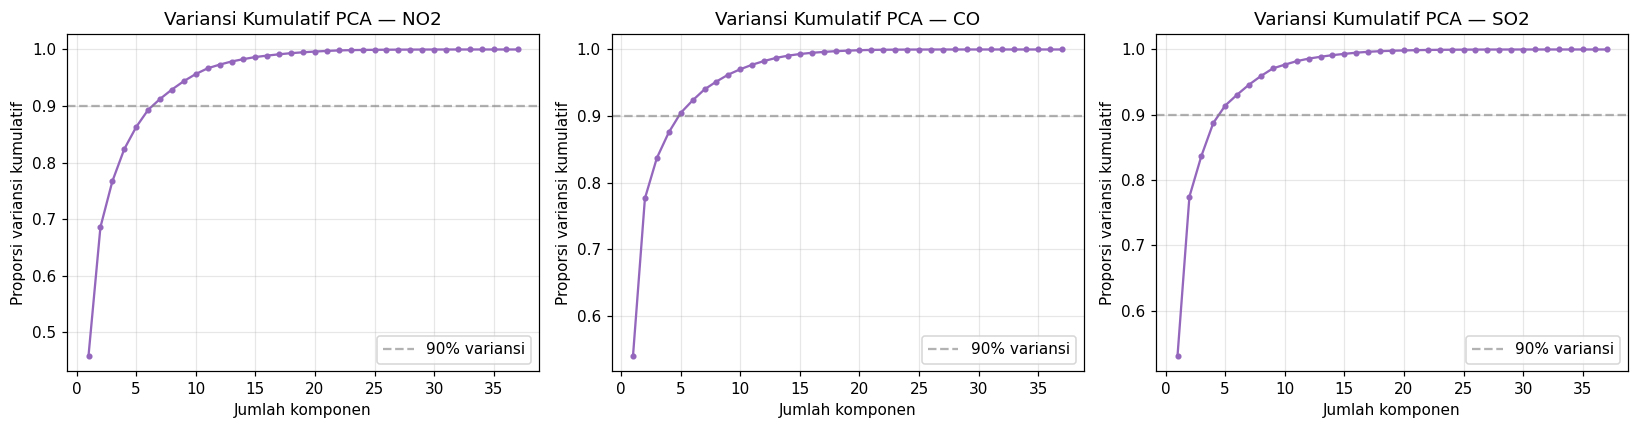

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, d) in zip(axes, processed.items()):
    cum = np.cumsum(d["pca_model"].explained_variance_ratio_)
    ax.plot(range(1, len(cum) + 1), cum, marker=".", color="tab:purple")
    ax.axhline(0.9, color="gray", linestyle="--", alpha=0.6, label="90% variansi")
    ax.set_title(f"Variansi Kumulatif PCA — {name}")
    ax.set_xlabel("Jumlah komponen")
    ax.set_ylabel("Proporsi variansi kumulatif")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Menentukan Jumlah Cluster Terbaik — Data Hasil PCA (37 komponen)

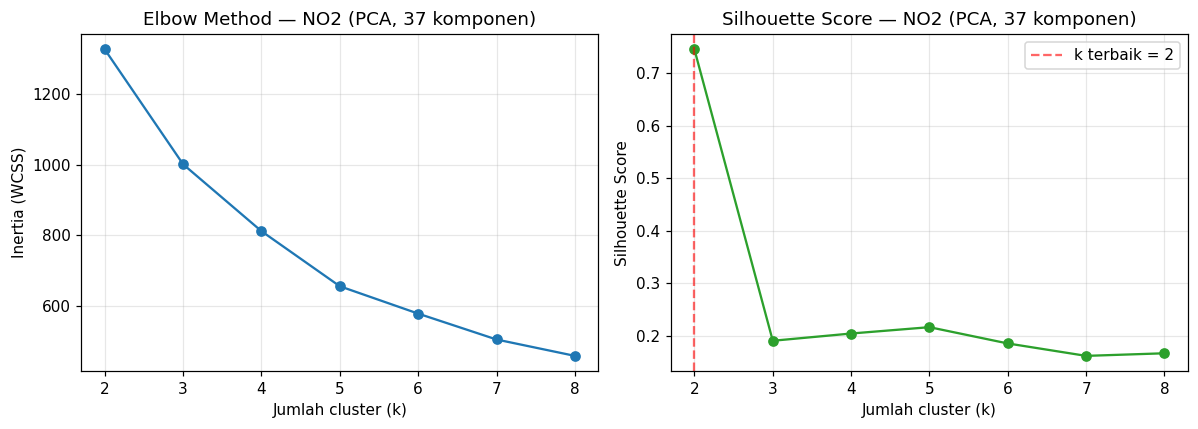

NO2: k terbaik = 2  (silhouette = 0.745)



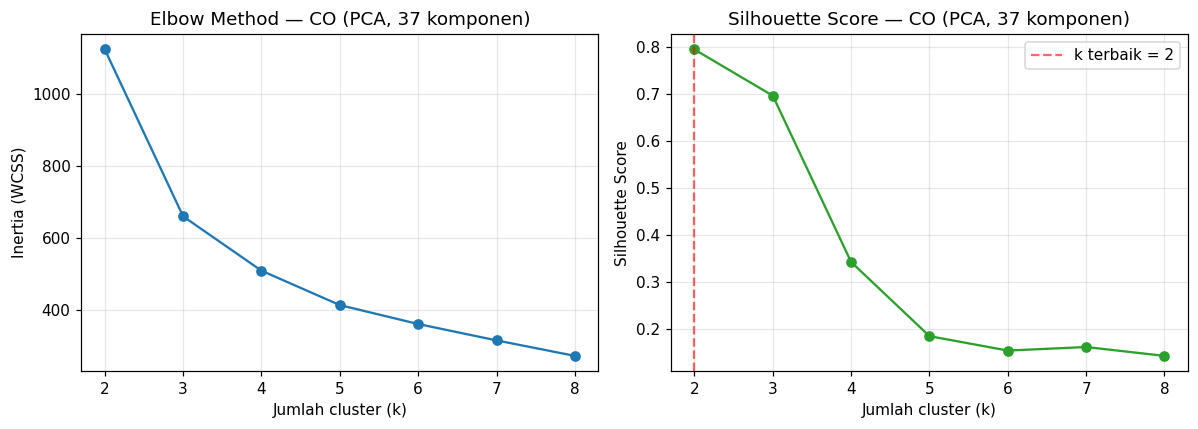

CO: k terbaik = 2  (silhouette = 0.795)



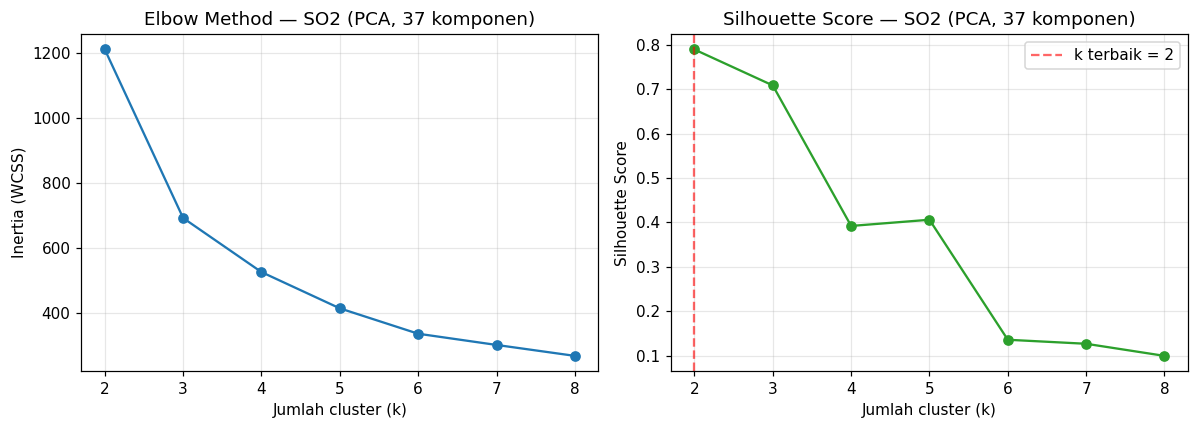

SO2: k terbaik = 2  (silhouette = 0.789)



In [14]:
pca_results = {}
for name, d in processed.items():
    res, k_best, sil_best = evaluate_k_range(d["X_pca"])
    pca_results[name] = (res, k_best, sil_best)
    plot_elbow_silhouette(res, f"{name} (PCA, {d['n_comp_actual']} komponen)")
    print(f"{name}: k terbaik = {k_best}  (silhouette = {sil_best:.3f})\n")

## 8. Menentukan Jumlah Cluster Terbaik — 68 Fitur Asli (Tanpa PCA)

Langkah yang persis sama diulang, kali ini langsung pada data yang sudah distandarisasi **tanpa** reduksi dimensi, sebagai pembanding.

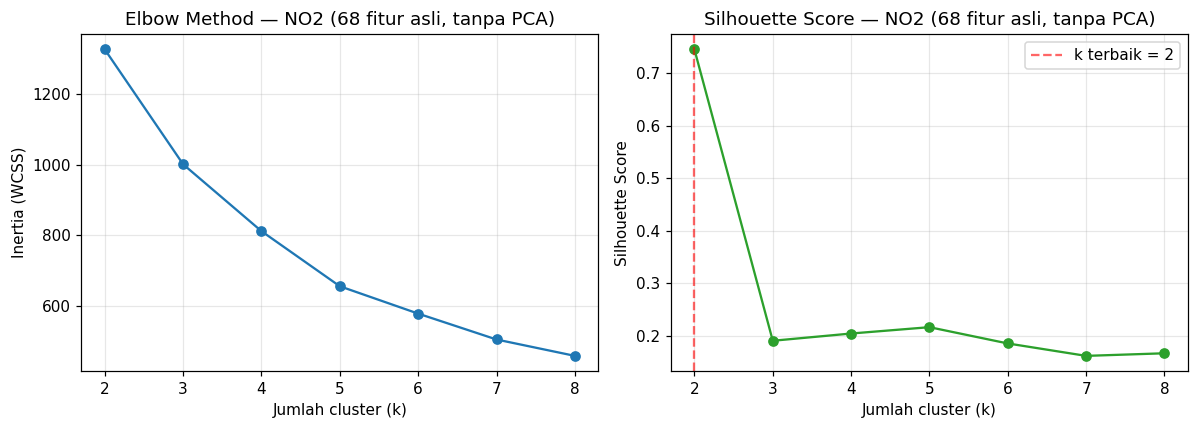

NO2: k terbaik = 2  (silhouette = 0.745)



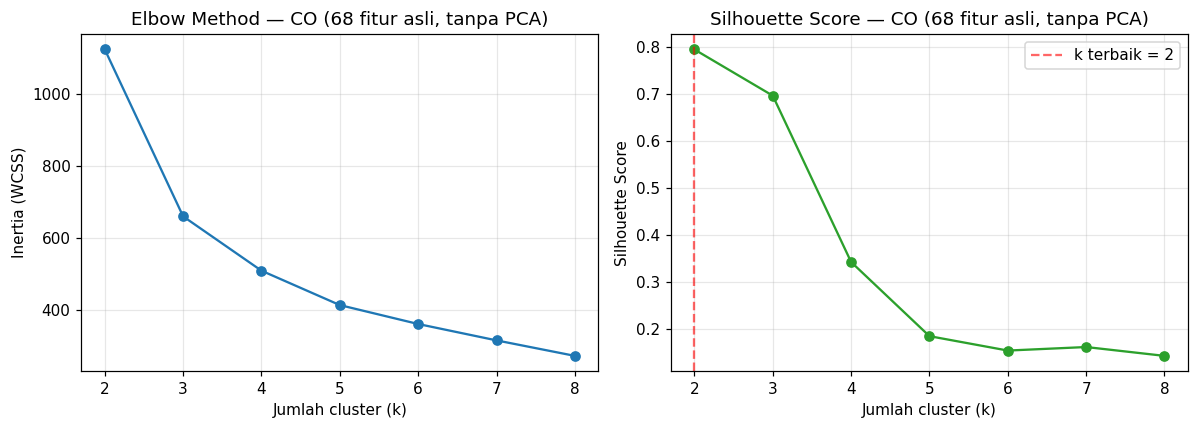

CO: k terbaik = 2  (silhouette = 0.795)



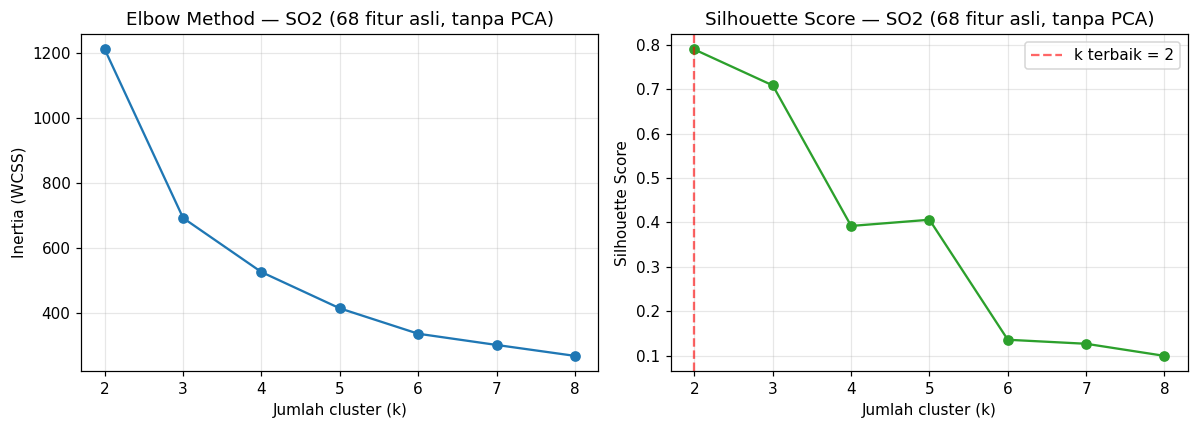

SO2: k terbaik = 2  (silhouette = 0.789)



In [15]:
full_results = {}
for name, d in processed.items():
    res, k_best, sil_best = evaluate_k_range(d["X_scaled"])
    full_results[name] = (res, k_best, sil_best)
    plot_elbow_silhouette(res, f"{name} (68 fitur asli, tanpa PCA)")
    print(f"{name}: k terbaik = {k_best}  (silhouette = {sil_best:.3f})\n")

## 9. Ringkasan & Perbandingan: PCA (37) vs 68 Fitur Asli

In [16]:
summary_rows = []
for name, d in processed.items():
    _, k_pca, sil_pca = pca_results[name]
    _, k_full, sil_full = full_results[name]
    summary_rows.append({
        "Polutan": name,
        "n_sampel": d["X_scaled"].shape[0],
        "n_fitur_dipakai": d["X_scaled"].shape[1],
        "Hopkins": round(d["hopkins"], 3),
        "n_komponen_PCA": d["n_comp_actual"],
        "Var._dijelaskan_PCA (%)": round(d["cum_var"] * 100, 1),
        "k_terbaik (PCA)": k_pca,
        "Silhouette (PCA)": round(sil_pca, 3),
        "k_terbaik (68 fitur)": k_full,
        "Silhouette (68 fitur)": round(sil_full, 3),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Polutan,n_sampel,n_fitur_dipakai,Hopkins,n_komponen_PCA,Var._dijelaskan_PCA (%),k_terbaik (PCA),Silhouette (PCA),k_terbaik (68 fitur),Silhouette (68 fitur)
0,NO2,37,66,0.842,37,100.0,2,0.745,2,0.745
1,CO,37,65,0.880,37,100.0,2,0.795,2,0.795
2,SO2,37,66,0.886,37,100.0,2,0.789,2,0.789
